# NETFLIX MOVIE DATA ANALYSIS

*   *`Importing required libraries`*

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

*   *`Loading CSV dataset`*

In [68]:
df = pd.read_csv('/content/mymoviedb.csv', engine='python')

In [69]:
# First 5 rows of the dataset.
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [70]:
# Last five rows of the dataset.
df.tail()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


# **Data Cleaning**

In [71]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


* *`We have few null values that we need to clean first.`*
* *`Also we have to change the datatypes of the columns:`*
  * *`Release_Date to datetime.`*
  * *`Vote_count to int64.`*
  * *`Vote_Average to float64.`*

In [72]:
# Removing null values.

In [73]:
df.isnull().sum()

,0
Release_Date,0
Title,9
Overview,9
Popularity,10
Vote_Count,10
Vote_Average,10
Original_Language,10
Genre,11
Poster_Url,11


In [74]:
df.dropna(inplace=True)

In [75]:
df.isnull().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


*All null values are cleaned.*

In [76]:
# Exploring Genres column
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


*`There are many whitespaces between genre which we might have to deal with later.`*

In [77]:
# checking data duplicates

In [78]:
df.duplicated().sum()

np.int64(0)

*`No duplicates present in the dataset.`*

*`Also, we don't need Overview, Original_Language and Poster-Url during analysis.`*

In [79]:
df.drop(columns=['Overview', 'Original_Language','Poster_Url'], inplace=True)

In [80]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [81]:
# Change the Datatype of the column Vote_Count to int64.

In [82]:
df['Vote_Count'] = df['Vote_Count'].astype('int64')
df['Vote_Count'].dtype

dtype('int64')

In [83]:
# Change the Datatype of the column Vote_Average to int64.

In [84]:
df['Vote_Average'] = df['Vote_Average'].astype('float64')
df['Vote_Average'].dtype

dtype('float64')

In [85]:
# Exploring summary of the dataset.
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9826.000000,9826.000000,9826.000000
mean,40.323951,1392.943721,6.439467
std,108.879332,2611.303856,1.129797
min,13.354000,0.000000,0.000000
25%,16.128250,146.000000,5.900000
50%,21.195000,444.000000,6.500000
75%,35.179250,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [86]:
# Change the Datatype of the column Release_Date to datetime.

In [87]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

In [88]:
# Confirming changes
df['Release_Date'].dtype

dtype('<M8[ns]')

In [89]:
# Now we can test it by extracting months, years etc.
df['Release_Date'] = df['Release_Date'].dt.year
print(df['Release_Date'].dtype)

int32


In [90]:
# Checking the datatypes of the columns now.
df.dtypes

,0
Release_Date,int32
Title,object
Popularity,float64
Vote_Count,int64
Vote_Average,float64
Genre,object


*`Now we have converted all the coulmns dataypes as we needed.`*

In [91]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


*`We will organise the data by vote_average and divide it into 4 parts: Popular, Average, Below_Average, and Not_popular, and cut the Vote_Average values to describe them more using the categorize_col() function.`*

In [92]:
def categorize_col(df, col, labels):

  edges = [df[col].describe()['min'],
         df[col].describe()['25%'],
         df[col].describe()['50%'],
         df[col].describe()['75%'],
         df[col].describe()['max']]

  df[col] = pd.cut(df[col], edges, labels=labels, duplicates= 'drop')
  return df

In [93]:
labels= ['Not Popular','Below_Average','Average','Popular']
categorize_col(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['Popular', 'Below_Average', 'Average', 'Not Popular', NaN]
Categories (4, object): ['Not Popular' < 'Below_Average' < 'Average' < 'Popular']

In [94]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_Average,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


In [95]:
# Exploring column Vote_Average
df['Vote_Average'].value_counts()

,count
Vote_Average,
Not Popular,2467
Popular,2450
Average,2411
Below_Average,2398


In [96]:
# Dropping null values.
df.dropna(inplace=True)

In [97]:
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


*`We will split genres into a list and then explode our dataframe to have only one genre per row for each movie.`*

In [99]:
df['Genre']= df['Genre'].str.split(', ')
df= df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [100]:
# Casting genre into a categorical data type.

In [101]:
df['Genre']= df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25551 non-null  int32   
 1   Title         25551 non-null  object  
 2   Popularity    25551 non-null  float64 
 3   Vote_Count    25551 non-null  int64   
 4   Vote_Average  25551 non-null  category
 5   Genre         25551 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [103]:
df.nunique()

,0
Release_Date,100
Title,9414
Popularity,8087
Vote_Count,3265
Vote_Average,4
Genre,19


*`Now, the data is cleaned and is ready for gathering insights.`*

# DATA VISUALISATION

*`We are using matplotlib and seaborn to visualise the data.`*

In [104]:
# setting up seaborn configurations.
sns.set_style('darkgrid')
sns.set_palette('deep')

# Q1: What is the most frequent genre in the dataset?

In [106]:
df['Genre'].describe()

,Genre
count,25551
unique,19
top,Drama
freq,3715


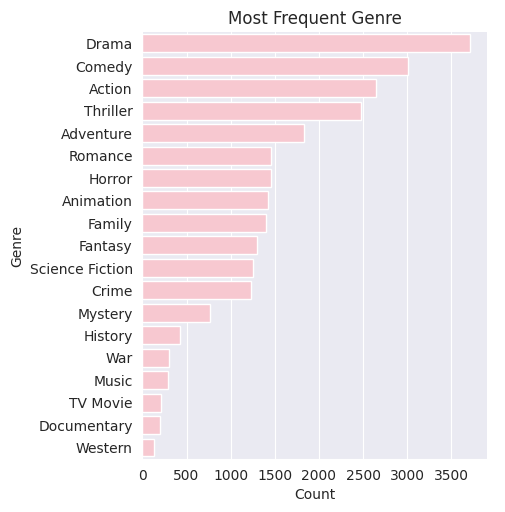

In [107]:
ax= sns.catplot(y='Genre', data=df, kind='count',
                order = df['Genre'].value_counts().index,
                color= 'pink')

plt.title('Most Frequent Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()


*`We can notice from the above visual that Drama genre is the most frequent genre in our dataset and has appeared more than 14% of the times among 19 other genres.`*

# Q2: What genres have the highest votes in the Vote_Average column?

In [109]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


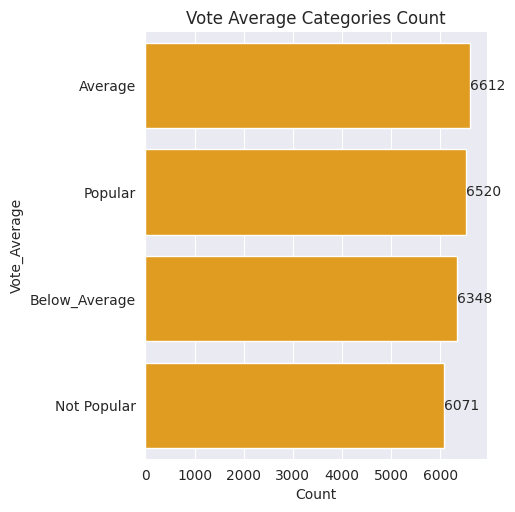

In [110]:
g= sns.catplot(y='Vote_Average', data=df, kind='count',
            order= df['Vote_Average'].value_counts().index,
            color='orange')
ax=g.ax

for container in ax.containers:
  ax.bar_label(container)

plt.title('Vote Average Categories Count')
plt.xlabel('Count')
plt.ylabel('Vote_Average')
plt.show()

*`We can infer that most of the average movies have the highest count.`*

# Q3: What movie got the highest popularity? What's its genre?

In [111]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure


In [112]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction


*`The movie with highest popularity is "Spider Man: No Way Home" and its genres are Action, Adventure, Science Fiction.`*

# Q4: What movie got the lowest popularity? What's its genre?

In [113]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25545,2021,The United States vs. Billie Holiday,13.354,152,Average,Music
25546,2021,The United States vs. Billie Holiday,13.354,152,Average,Drama
25547,2021,The United States vs. Billie Holiday,13.354,152,Average,History
25548,1984,Threads,13.354,186,Popular,War
25549,1984,Threads,13.354,186,Popular,Drama
25550,1984,Threads,13.354,186,Popular,Science Fiction


*`Movies with the lowest popularity:`*

* *`The United States vs. Billie Holiday
and its Genres are:- Music, Drama, History. `*

* *`Threads and its genres are:- War, Drama, Science Fiction. `*






# Q5: Which year has the most filmmed movies?

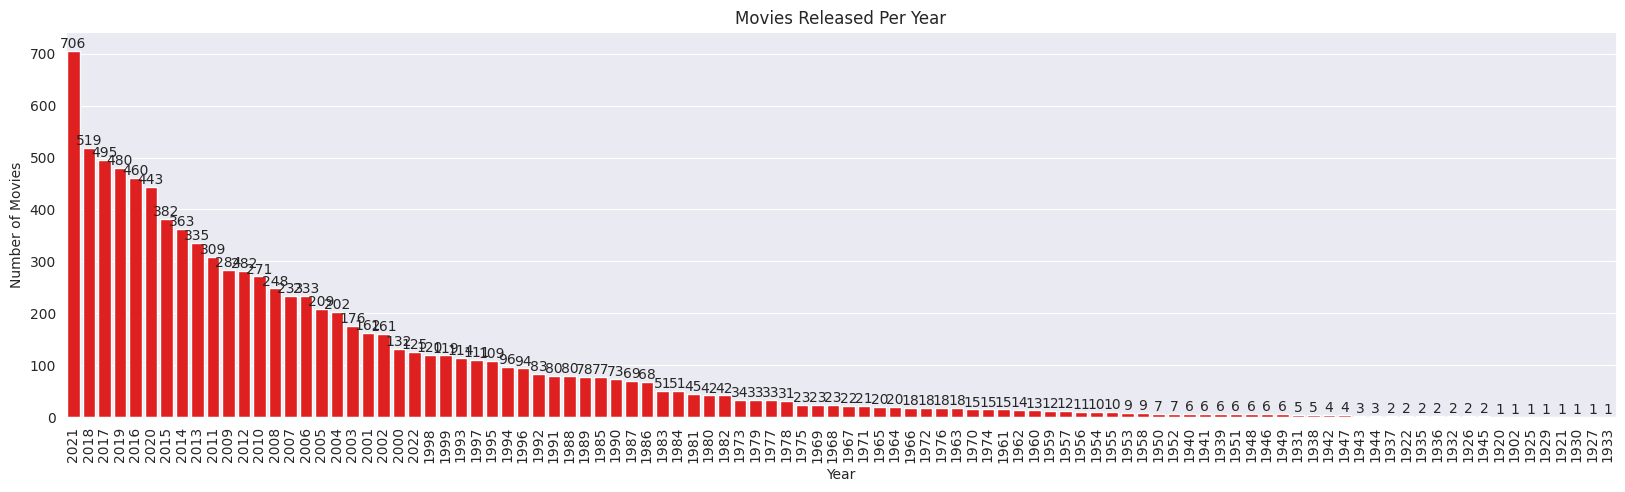

In [124]:
plt.figure(figsize=(20,5))

ax = sns.countplot(
    x='Release_Date',
    data=df.drop_duplicates(subset='Title'),
    order=df.drop_duplicates(subset='Title')['Release_Date'].value_counts().index,
    color='red'
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=90)

plt.title('Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')

plt.show()

*`2021 has the highest release count.`*

# Conclusion

Q1: What is the most frequent genre in the dataset?**

 * Drama genre is the most frequent genre in our dataset and has appeared more than
  14% of the times among 19 other genres.

Q2: What genres has highest votes ?

  * We have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the
  highest popularity among fans by being having more than 18.5% of movies popularities.

Q3: What movie got the highest popularity ? what's its genre ?

  * Spider-Man: No Way Home has the highest popularity rate in our dataset and it has
  genres of Action , Adventure and Sience Fiction .

Q4: What movie got the lowest popularity ? what's its genre ?

  * The United States, thread' has the lowest rate in our dataset
  and it has genres: music, drama, 'war', 'sci-fi', and history.

Q5: Which year has the most filmmed movies?
  * Year 2021 has the highest filmmaking rate in our dataset.



